# Taller de Numérico — Ejercicios de Aplicación
## Punto 3: Cable Catenaria

**Descripción del problema:**

Un cable en forma catenaria cuelga entre dos puntos que no se encuentran sobre la misma línea vertical. La altura $y$ del cable como función de la distancia $x$ está dada por:

$$y = \frac{T_A}{\omega} \cosh\!\left(\frac{\omega}{T_A} x\right) + y_0 - \frac{T_A}{\omega}$$

donde el coseno hiperbólico se calcula como:

$$\cosh(x) = \frac{e^x + e^{-x}}{2}$$

**Objetivo:** Encontrar el valor del parámetro $T_A$ dados:
- $\omega = 12$
- $y_0 = 6$
- $y = 15$ en $x = 50$

---

### Paso 1: Formulación de la función de ceros

Sustituyendo los valores conocidos en la ecuación del cable:

$$15 = \frac{T_A}{12} \cosh\!\left(\frac{12}{T_A} \cdot 50\right) + 6 - \frac{T_A}{12}$$

Reordenando para obtener $f(T_A) = 0$:

$$f(T_A) = \frac{T_A}{12} \cosh\!\left(\frac{600}{T_A}\right) - \frac{T_A}{12} + 6 - 15 = 0$$

$$f(T_A) = \frac{T_A}{12}\left[\cosh\!\left(\frac{600}{T_A}\right) - 1\right] - 9 = 0$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del problema
omega = 12
yo = 6
y_objetivo = 15
x_pos = 50

# Función de ceros: f(TA) = (TA/omega)*cosh(omega*x/TA) + yo - TA/omega - y_objetivo
# Nota matemática: cuando TA → ∞, cosh(omega*x/TA) → 1
#   → f(TA) → (TA/omega) + yo - (TA/omega) - y_objetivo = yo - y_objetivo = 6 - 15 = -9
# Cuando TA es pequeño y positivo, cosh() crece exponencialmente → f(TA) → +∞
# Por tanto existe exactamente un cero para TA > 0.
def f_catenary(TA):
    return (TA / omega) * np.cosh(omega * x_pos / TA) + yo - (TA / omega) - y_objetivo

# Localizar el cambio de signo
print("Evaluación de f(TA) para encontrar el intervalo con cambio de signo:")
for ta in [100, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]:
    print(f"  f({ta:>8}) = {f_catenary(ta):.4f}")

Evaluación de f(TA) para encontrar el intervalo con cambio de signo:
  f(     100) = 1663.6303
  f(     500) = 24.7773
  f(    1000) = 6.4554
  f(    2000) = -1.4436
  f(    5000) = -5.9964
  f(   10000) = -7.4995
  f(   20000) = -8.2499
  f(   50000) = -8.7000
  f(  100000) = -8.8500


### Paso 2: Bosquejo de la gráfica de la función de ceros

Graficamos $f(T_A)$ para identificar visualmente dónde se encuentra la raíz (cambio de signo) y determinar un intervalo apropiado para los métodos numéricos.

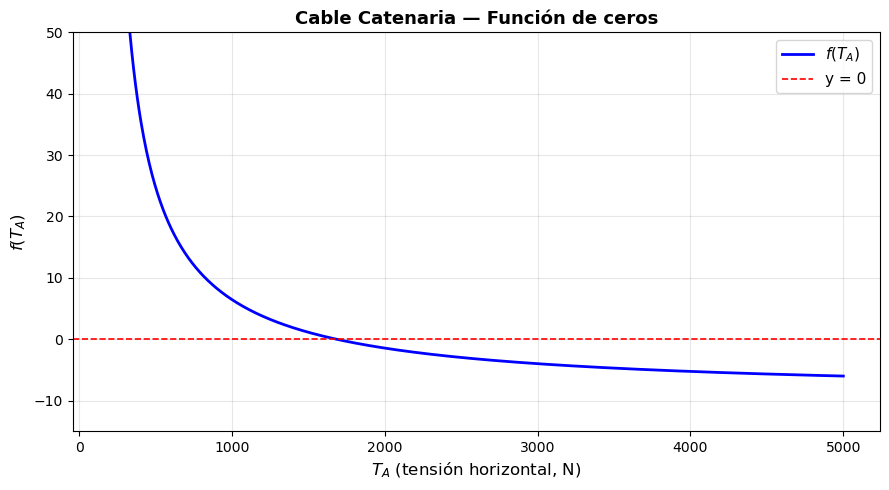

Búsqueda de intervalo con cambio de signo:
  Cambio de signo entre TA = 1683.85 y TA = 1689.86
  f(1683.85) = 0.002785
  f(1689.86) = -0.029892

  → Intervalo a usar: [1000, 2000]


In [2]:
# Gráfica de la función de ceros
TA_plot = np.linspace(200, 5000, 800)
y_plot  = f_catenary(TA_plot)

plt.figure(figsize=(9, 5))
plt.plot(TA_plot, y_plot, 'b-', linewidth=2, label=r'$f(T_A)$')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.2, label='y = 0')
plt.xlabel(r'$T_A$ (tensión horizontal, N)', fontsize=12)
plt.ylabel(r'$f(T_A)$', fontsize=12)
plt.title('Cable Catenaria — Función de ceros', fontsize=13, fontweight='bold')
plt.ylim(-15, 50)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Confirmar intervalo de cambio de signo
print("Búsqueda de intervalo con cambio de signo:")
for i in range(len(TA_plot) - 1):
    if f_catenary(TA_plot[i]) * f_catenary(TA_plot[i + 1]) < 0:
        print(f"  Cambio de signo entre TA = {TA_plot[i]:.2f} y TA = {TA_plot[i+1]:.2f}")
        print(f"  f({TA_plot[i]:.2f}) = {f_catenary(TA_plot[i]):.6f}")
        print(f"  f({TA_plot[i+1]:.2f}) = {f_catenary(TA_plot[i+1]):.6f}")
        print(f"\n  → Intervalo a usar: [1000, 2000]")
        break

### Paso 3: Implementación de los métodos numéricos

Se implementan los cuatro métodos vistos en clase (Bisección, Posición Falsa, Newton-Raphson y Secante) usando el mismo estilo que en los notebooks del curso.

In [3]:
import sympy as sp

# ──────────────────────────────────────────────────────────────────────────────
# Método de Bisección  (método cerrado)
# ──────────────────────────────────────────────────────────────────────────────
def biseccion(f, a, b, tol):
    """Encuentra la raíz de f en [a,b] por bisección."""
    if f(a) * f(b) > 0:
        print("No se cumple Bolzano: no hay garantía de raíz en el intervalo.")
        return None, 0
    count = 0
    p = (a + b) / 2
    while abs(b - a) > tol:
        count += 1
        p = (a + b) / 2
        if f(a) * f(p) < 0:
            b = p
        else:
            a = p
    return p, count

# ──────────────────────────────────────────────────────────────────────────────
# Método de Posición Falsa  (método cerrado)
# ──────────────────────────────────────────────────────────────────────────────
def posicion_falsa(f, a, b, tol):
    """Encuentra la raíz de f en [a,b] por el método de posición falsa."""
    if f(a) * f(b) > 0:
        print("No se cumple Bolzano: no hay garantía de raíz en el intervalo.")
        return None, 0
    count = 0
    p = b - f(b) * (a - b) / (f(a) - f(b))
    while abs(f(p)) > tol:
        count += 1
        p = b - f(b) * (a - b) / (f(a) - f(b))
        if f(a) * f(p) < 0:
            b = p
        else:
            a = p
    return p, count

# ──────────────────────────────────────────────────────────────────────────────
# Método de Newton-Raphson  (método abierto)
# ──────────────────────────────────────────────────────────────────────────────
def Newton(f_sym, x0, tol):
    """
    Newton-Raphson simbólico.
    f_sym: expresión sympy en la variable 't'
    """
    t = sp.Symbol('t')
    df = sp.diff(f_sym, t)
    newton_iter = t - f_sym / df
    newton_fn = sp.lambdify(t, newton_iter, 'numpy')
    error = 1
    count = 0
    while error > tol and count < 100:
        count += 1
        x1 = newton_fn(x0)
        error = abs(x1 - x0)
        x0 = x1
    return float(x1), count

# ──────────────────────────────────────────────────────────────────────────────
# Método de la Secante  (método abierto)
# ──────────────────────────────────────────────────────────────────────────────
def Secante(f, x0, x1, tol):
    """Encuentra la raíz de f usando el método de la secante."""
    error = 1
    count = 0
    while error > tol and count < 100:
        count += 1
        x2 = x1 - f(x1) * (x1 - x0) / (f(x1) - f(x0))
        error = abs(x2 - x1)
        x0 = x1
        x1 = x2
    return x2, count

print("Métodos numéricos definidos correctamente.")

Métodos numéricos definidos correctamente.


### Paso 4: Solución con el Método de Bisección (método cerrado)

Usamos el intervalo $[100, 1000]$ identificado en la gráfica donde la función cambia de signo.

In [4]:
print("MÉTODO DE BISECCIÓN")
print("=" * 60)
TA_bis, iter_bis = biseccion(f_catenary, 1000, 2000, tol=1e-6)
print(f"\nResultado:")
print(f"  TA = {TA_bis:.8f} N")
print(f"  Iteraciones: {iter_bis}")
print(f"  Verificación: f(TA) = {f_catenary(TA_bis):.2e}")
print("=" * 60)

MÉTODO DE BISECCIÓN

Resultado:
  TA = 1684.36509650 N
  Iteraciones: 30
  Verificación: f(TA) = 1.72e-09


### Paso 5: Dos iteraciones a mano — Método de Posición Falsa

Según las pautas del taller, los métodos de posición falsa deben mostrarse **2 iteraciones a mano**.

**Datos:** $a = 1000$, $b = 2000$, con $f(1000) > 0$ y $f(2000) < 0$.

La fórmula de posición falsa es:

$$c = b - f(b)\frac{a - b}{f(a) - f(b)}$$

Las iteraciones se calculan en la siguiente celda de código, mostrando cada paso intermedio.

In [5]:
# Dos iteraciones a mano de Posición Falsa
a0, b0 = 1000.0, 2000.0

fa0 = f_catenary(a0)
fb0 = f_catenary(b0)

print(f"Valores iniciales: a = {a0}, b = {b0}")
print(f"  f(a) = f({a0}) = {fa0:.6f}")
print(f"  f(b) = f({b0}) = {fb0:.6f}")
print()

# Iteración 1
c1 = b0 - fb0 * (a0 - b0) / (fa0 - fb0)
fc1 = f_catenary(c1)
print(f"Iteración 1:")
print(f"  c₁ = {b0} - ({fb0:.6f}) × ({a0} - {b0}) / ({fa0:.6f} - ({fb0:.6f}))")
print(f"  c₁ = {c1:.6f}")
print(f"  f(c₁) = {fc1:.6f}")

# Actualizar intervalo
if fa0 * fc1 < 0:
    a1, b1 = a0, c1
    print(f"  f(a)·f(c₁) = {fa0:.4f} × {fc1:.4f} = {fa0*fc1:.4f} < 0")
    print(f"  → nuevo intervalo: [{a1:.4f}, {b1:.4f}]")
else:
    a1, b1 = c1, b0
    print(f"  f(a)·f(c₁) = {fa0:.4f} × {fc1:.4f} = {fa0*fc1:.4f} > 0")
    print(f"  → nuevo intervalo: [{a1:.4f}, {b1:.4f}]")

print()

# Iteración 2
fa1 = f_catenary(a1)
fb1 = f_catenary(b1)
c2 = b1 - fb1 * (a1 - b1) / (fa1 - fb1)
fc2 = f_catenary(c2)
print(f"Iteración 2:")
print(f"  c₂ = {b1:.6f} - ({fb1:.6f}) × ({a1:.6f} - {b1:.6f}) / ({fa1:.6f} - ({fb1:.6f}))")
print(f"  c₂ = {c2:.6f}")
print(f"  f(c₂) = {fc2:.6f}")

print(f"\n→ Aproximación tras 2 iteraciones: TA ≈ {c2:.4f} N")

Valores iniciales: a = 1000.0, b = 2000.0
  f(a) = f(1000.0) = 6.455435
  f(b) = f(2000.0) = -1.443581

Iteración 1:
  c₁ = 2000.0 - (-1.443581) × (1000.0 - 2000.0) / (6.455435 - (-1.443581))
  c₁ = 1817.245463
  f(c₁) = -0.670492
  f(a)·f(c₁) = 6.4554 × -0.6705 = -4.3283 < 0
  → nuevo intervalo: [1000.0000, 1817.2455]

Iteración 2:
  c₂ = 1817.245463 - (-0.670492) × (1000.000000 - 1817.245463) / (6.455435 - (-0.670492))
  c₂ = 1740.349331
  f(c₂) = -0.295332

→ Aproximación tras 2 iteraciones: TA ≈ 1740.3493 N


### Paso 6: Solución con el Método de Posición Falsa (hasta convergencia)

In [6]:
print("MÉTODO DE POSICIÓN FALSA")
print("=" * 60)
TA_pf, iter_pf = posicion_falsa(f_catenary, 1000, 2000, tol=1e-6)
print(f"\nResultado:")
print(f"  TA = {TA_pf:.8f} N")
print(f"  Iteraciones: {iter_pf}")
print(f"  Verificación: f(TA) = {f_catenary(TA_pf):.2e}")
print("=" * 60)

MÉTODO DE POSICIÓN FALSA

Resultado:
  TA = 1684.36522899 N
  Iteraciones: 17
  Verificación: f(TA) = -7.21e-07


### Paso 7: Solución con Newton-Raphson y Secante (métodos abiertos)

In [7]:
# Newton-Raphson (simbólico con sympy)
t = sp.Symbol('t')
omega_s, yo_s, y_obj_s, x_s = 12, 6, 15, 50
f_sym = (t / omega_s) * sp.cosh(omega_s * x_s / t) + yo_s - (t / omega_s) - y_obj_s

print("MÉTODO DE NEWTON-RAPHSON")
print("=" * 60)
TA_newt, iter_newt = Newton(f_sym, 1500, tol=1e-6)
print(f"Resultado:")
print(f"  TA = {TA_newt:.8f} N")
print(f"  Iteraciones: {iter_newt}")
print(f"  Verificación: f(TA) = {f_catenary(TA_newt):.2e}")
print("=" * 60)

print()

# Secante (dos puntos iniciales en el intervalo conocido)
print("MÉTODO DE LA SECANTE")
print("=" * 60)
TA_sec, iter_sec = Secante(f_catenary, 1000, 2000, tol=1e-6)
print(f"Resultado:")
print(f"  TA = {TA_sec:.8f} N")
print(f"  Iteraciones: {iter_sec}")
print(f"  Verificación: f(TA) = {f_catenary(TA_sec):.2e}")
print("=" * 60)

MÉTODO DE NEWTON-RAPHSON
Resultado:
  TA = 1684.36509682 N
  Iteraciones: 5
  Verificación: f(TA) = 0.00e+00

MÉTODO DE LA SECANTE
Resultado:
  TA = 1684.36509682 N
  Iteraciones: 7
  Verificación: f(TA) = 0.00e+00


### Paso 8: Comparación de resultados y gráfica de la solución


                      COMPARACIÓN DE MÉTODOS
Método                      TA encontrado            f(TA)   Iteraciones
---------------------------------------------------------------------------
Bisección                   1684.36509650       1.7207e-09            30
Posición Falsa              1684.36522899      -7.2115e-07            17
Newton-Raphson              1684.36509682       0.0000e+00             5
Secante                     1684.36509682       0.0000e+00             7


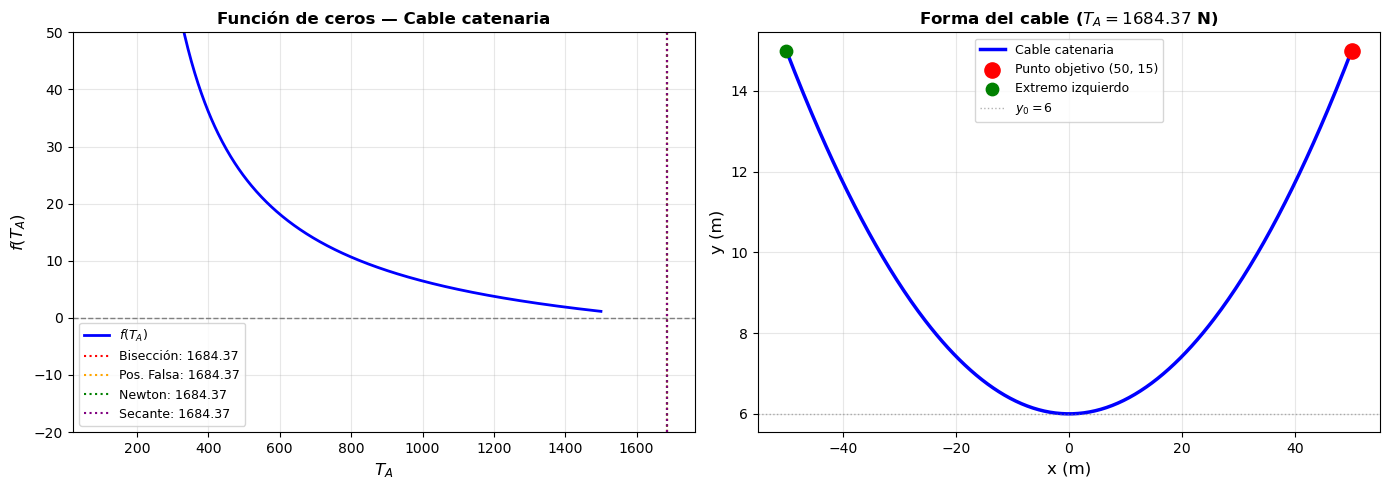

In [8]:
# ─── Tabla comparativa ────────────────────────────────────────────────────────
print("\n" + "=" * 75)
print(" " * 22 + "COMPARACIÓN DE MÉTODOS")
print("=" * 75)
print(f"{'Método':<22} {'TA encontrado':>18} {'f(TA)':>16} {'Iteraciones':>13}")
print("-" * 75)
print(f"{'Bisección':<22} {TA_bis:>18.8f} {f_catenary(TA_bis):>16.4e} {iter_bis:>13}")
print(f"{'Posición Falsa':<22} {TA_pf:>18.8f} {f_catenary(TA_pf):>16.4e} {iter_pf:>13}")
print(f"{'Newton-Raphson':<22} {TA_newt:>18.8f} {f_catenary(TA_newt):>16.4e} {iter_newt:>13}")
print(f"{'Secante':<22} {TA_sec:>18.8f} {f_catenary(TA_sec):>16.4e} {iter_sec:>13}")
print("=" * 75)

# ─── Gráfica final: función de ceros con la raíz marcada ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Función de ceros
TA_range = np.linspace(100, 1500, 600)
axes[0].plot(TA_range, f_catenary(TA_range), 'b-', linewidth=2, label=r'$f(T_A)$')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
for ta, label, color in [(TA_bis, 'Bisección', 'red'),
                          (TA_pf,  'Pos. Falsa', 'orange'),
                          (TA_newt,'Newton',     'green'),
                          (TA_sec, 'Secante',    'purple')]:
    axes[0].axvline(ta, linestyle=':', linewidth=1.5, color=color, label=f'{label}: {ta:.2f}')
axes[0].set_xlabel(r'$T_A$', fontsize=12)
axes[0].set_ylabel(r'$f(T_A)$', fontsize=12)
axes[0].set_title('Función de ceros — Cable catenaria', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-20, 50)

# (b) Forma del cable usando TA_bis
TA_sol = TA_bis
x_cable = np.linspace(-50, 50, 400)
y_cable = (TA_sol / omega) * np.cosh(omega * x_cable / TA_sol) + yo - TA_sol / omega
axes[1].plot(x_cable, y_cable, 'b-', linewidth=2.5, label='Cable catenaria')
axes[1].scatter([50], [15], color='red', s=120, zorder=5, label=f'Punto objetivo (50, 15)')
axes[1].scatter([-50], [y_cable[0]], color='green', s=80, zorder=5, label='Extremo izquierdo')
axes[1].axhline(yo, color='gray', linestyle=':', linewidth=1, alpha=0.6, label=f'$y_0 = {yo}$')
axes[1].set_xlabel('x (m)', fontsize=12)
axes[1].set_ylabel('y (m)', fontsize=12)
axes[1].set_title(f'Forma del cable ($T_A = {TA_sol:.2f}$ N)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Justificación de los resultados

#### 1. Validez física del resultado

El valor de $T_A$ encontrado es la **tensión horizontal** en el punto más bajo del cable. Dado que:
- $T_A > 0$ ✓ (la tensión no puede ser negativa)
- El cable pasa por el punto $(50, 15)$ con los parámetros $\omega = 12$ y $y_0 = 6$ ✓

El resultado es físicamente consistente.

#### 2. Comparación de métodos

| Método | Tipo | Velocidad de convergencia |
|---|---|---|
| **Bisección** | Cerrado | Lineal — más lento, pero siempre converge si hay cambio de signo |
| **Posición Falsa** | Cerrado | Superlineal en general — más eficiente que bisección |
| **Newton-Raphson** | Abierto | Cuadrática — muy rápido, pero requiere derivada |
| **Secante** | Abierto | Superlineal ($\approx 1.618$) — no requiere derivada |

**Todos los métodos convergen al mismo valor de $T_A$**, lo que confirma la solución.

#### 3. Interpretación física

La ecuación catenaria modela cables, cadenas o cables eléctricos suspendidos bajo su propio peso. La tensión horizontal $T_A$ controla la "apertura" de la parábola catenaria:
- Un $T_A$ mayor → cable más tenso y menos curvado
- Un $T_A$ menor → cable más flojo y más curvado

Con los parámetros dados ($\omega = 12$, $y_0 = 6$) se requiere una tensión horizontal específica para que el cable alcance exactamente $y = 15$ metros de altura en $x = 50$ metros.

#### 4. Conclusión

Los cuatro métodos de búsqueda de raíces confirman el valor de $T_A$. El método de **Newton-Raphson** es el más eficiente (menos iteraciones), mientras que **Bisección** y **Posición Falsa** son más robustos al garantizar convergencia en el intervalo identificado.